### Imports

In [2]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
import importlib
import joblib

sys.path.append("..")

import src.preprocessing.feature_engineering as fe
importlib.reload(fe)

prepare_features = fe.prepare_features
build_health_index_ae = fe.build_health_index_ae
add_health_label_from_hi = fe.add_health_label_from_hi

set_config(transform_output="pandas")

DATA_PATH = "../data/raw/predictive_maintenance_v3.csv"
PROCESSED_PATH = "../data/processed"
MODELS_PATH = "../models"

os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

In [3]:
def check_df(name, df):
    print(f"\n{name}")
    print("shape:", df.shape)
    print("index unique:", df.index.is_unique)
    print("colonnes:", df.columns.tolist())

### Chargement des données

In [4]:
df_raw = pd.read_csv(DATA_PATH)
df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"], errors="coerce")

check_df("df_raw", df_raw)
df_raw.head()


df_raw
shape: (24042, 15)
index unique: True
colonnes: ['timestamp', 'machine_id', 'machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'failure_type', 'estimated_repair_cost']


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


Retrait de la colonne à fuite possible

In [5]:
df_base = df_raw.drop(columns=["estimated_repair_cost"], errors="ignore").copy()

check_df("df_base", df_base)
df_base.head()


df_base
shape: (24042, 14)
index unique: True
colonnes: ['timestamp', 'machine_id', 'machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'failure_type']


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none


### Feature engineering

In [6]:
df_features = prepare_features(df_base)

check_df("df_features", df_features)
df_features.head()


df_features
shape: (24042, 20)
index unique: True
colonnes: ['timestamp', 'machine_id', 'machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'failure_type', 'temp_gap', 'vibration_rpm_interaction', 'pressure_current_interaction', 'vibration_delta', 'temperature_delta', 'anomaly_trend_raw']


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,temp_gap,vibration_rpm_interaction,pressure_current_interaction,vibration_delta,temperature_delta,anomaly_trend_raw
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,35.61,697.329,120.360,0.00,0.00,0.000
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,30.38,674.700,125.080,-0.06,-8.93,0.000
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,36.10,612.517,NaN,-0.04,9.12,3.648
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,29.64,661.504,108.254,0.05,-6.66,0.030
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,30.59,776.072,98.568,0.12,-1.65,0.072


In [7]:
df_final, autoencoder, imputer_ae, scaler_ae = build_health_index_ae(
    df_features,
    sensor_features=[
        "vibration_rms",
        "temperature_motor",
        "pressure_level",
        "rpm"
    ],
    target_failure_col="failure_within_24h",
    random_state=42,
    epochs=100,
    batch_size=32,
    patience=10
)

In [8]:
df_final = add_health_label_from_hi(df_final, hi_col="health_index_ae")

print("NaN dans health_index_ae :", df_final["health_index_ae"].isna().sum())
print(df_final["health_index_ae"].describe())
print(df_final["health_status"].value_counts())

NaN dans health_index_ae : 0
count    24042.000000
mean         0.967134
std          0.123830
min          0.000000
25%          0.984992
50%          0.992597
75%          0.996977
max          1.000000
Name: health_index_ae, dtype: float64
health_status
good        23315
critical      455
warning       272
Name: count, dtype: int64


In [9]:
new_cols = [
    "vibration_delta",
    "temperature_delta",
    "anomaly_trend_raw",
    "reconstruction_error",
    "reconstruction_error_norm",
    "health_index_ae",
    "health_status"
]

df_final[new_cols].head()

,vibration_delta,temperature_delta,anomaly_trend_raw,reconstruction_error,reconstruction_error_norm,health_index_ae,health_status
0,0.00,0.00,0.000,0.000004,0.004974,0.995026,good
1,-0.06,-8.93,0.000,0.000004,0.004555,0.995445,good
2,-0.04,9.12,3.648,0.000003,0.003181,0.996819,good
3,0.05,-6.66,0.030,0.000003,0.003954,0.996046,good
4,0.12,-1.65,0.072,0.000003,0.003573,0.996427,good


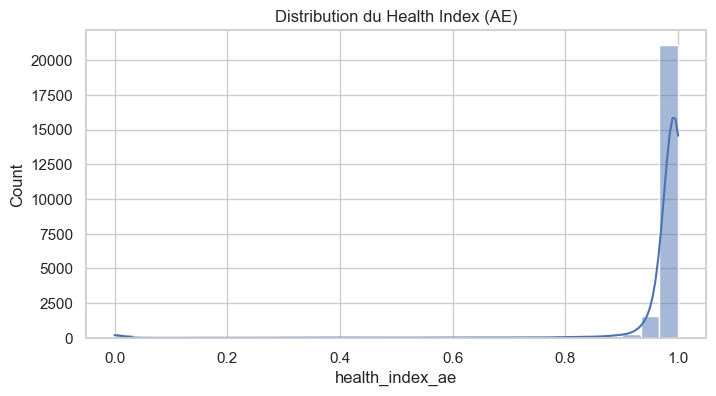

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(df_final["health_index_ae"], bins=30, kde=True)
plt.title("Distribution du Health Index (AE)")
plt.xlabel("health_index_ae")
plt.show()

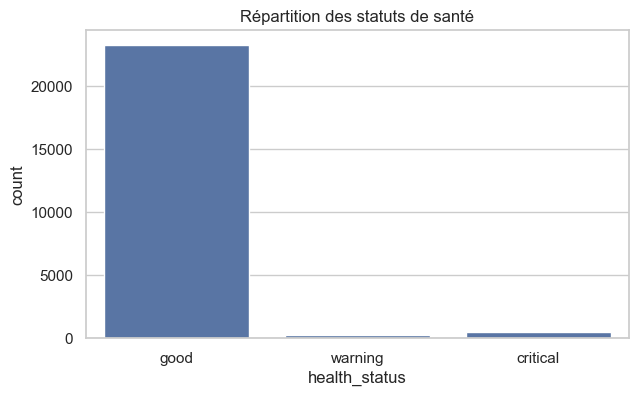

In [11]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df_final,
    x="health_status",
    order=["good", "warning", "critical"]
)
plt.title("Répartition des statuts de santé")
plt.xlabel("health_status")
plt.show()

In [12]:
df_final.groupby("failure_within_24h")["health_index_ae"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
failure_within_24h,,,,
0,20482,0.984639,0.993575,0.058661
1,3560,0.866426,0.971578,0.268083


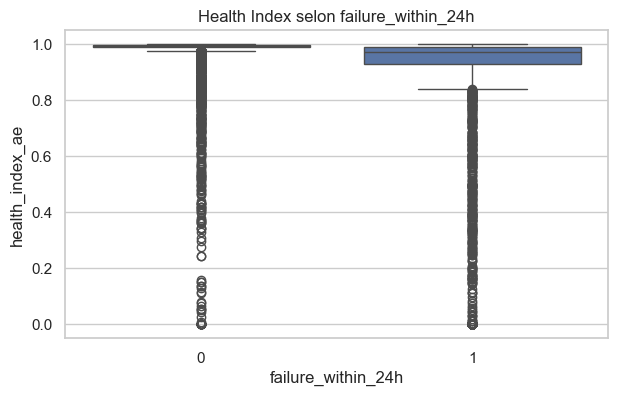

In [13]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_final, x="failure_within_24h", y="health_index_ae")
plt.title("Health Index selon failure_within_24h")
plt.xlabel("failure_within_24h")
plt.ylabel("health_index_ae")
plt.show()

In [14]:
print("Colonnes finales du dataset enrichi :")
print(df_final.columns.tolist())

Colonnes finales du dataset enrichi :
['timestamp', 'machine_id', 'machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'failure_type', 'temp_gap', 'vibration_rpm_interaction', 'pressure_current_interaction', 'vibration_delta', 'temperature_delta', 'anomaly_trend_raw', 'reconstruction_error', 'reconstruction_error_norm', 'health_index_ae', 'health_status']


In [15]:
df_final.to_csv(f"{PROCESSED_PATH}/health_index_ae_dataset.csv", index=False)
print("Dataset enrichi sauvegardé dans data/processed/health_index_ae_dataset.csv")

Dataset enrichi sauvegardé dans data/processed/health_index_ae_dataset.csv


In [16]:
autoencoder.save(f"{MODELS_PATH}/health_index_autoencoder.keras")
joblib.dump(imputer_ae, f"{MODELS_PATH}/health_index_ae_imputer.joblib")
joblib.dump(scaler_ae, f"{MODELS_PATH}/health_index_ae_scaler.joblib")

print("Autoencodeur, imputer et scaler sauvegardés.")

Autoencodeur, imputer et scaler sauvegardés.


In [17]:
cols_to_show = [
    "vibration_rms",
    "temperature_motor",
    "pressure_level",
    "rpm",
    "failure_within_24h",
    "reconstruction_error",
    "reconstruction_error_norm",
    "health_index_ae",
    "health_status"
]

df_final.sort_values("health_index_ae", ascending=True)[cols_to_show].head(10)

,vibration_rms,temperature_motor,pressure_level,rpm,failure_within_24h,reconstruction_error,reconstruction_error_norm,health_index_ae,health_status
4290,NaN,79.01,NaN,NaN,1,0.004355,1.0,0.0,critical
13447,1.30,80.85,48.6,655.9,1,0.004026,1.0,0.0,critical
8543,NaN,80.61,109.7,1086.4,1,0.001635,1.0,0.0,critical
21894,2.10,77.01,57.3,436.2,1,0.002386,1.0,0.0,critical
21897,2.00,69.16,55.5,456.6,1,0.001179,1.0,0.0,critical
21919,1.86,74.71,58.7,456.1,1,0.002062,1.0,0.0,critical
19651,1.41,81.21,39.9,304.8,1,0.002935,1.0,0.0,critical
19652,3.19,80.91,47.5,306.8,1,0.001902,1.0,0.0,critical
19654,1.30,78.77,42.8,300.1,1,0.000895,1.0,0.0,critical
11668,NaN,68.59,NaN,1254.1,0,0.000712,1.0,0.0,critical


## Conclusion preprocessing avec autoencodeur

Dans cette nouvelle approche, nous avons remplacé le calcul manuel du Health Score par un **Health Index construit via autoencodeur non supervisé**.

### Principe
- L’autoencodeur est entraîné uniquement sur les observations normales (`failure_within_24h = 0`).
- Il apprend donc le comportement “normal” des machines.
- Lorsqu’on l’applique à tout le dataset, une observation anormale est moins bien reconstruite et génère une erreur plus élevée.
- Cette erreur de reconstruction est ensuite normalisée puis transformée en Health Index :

\[
HI = 1 - \text{erreur de reconstruction normalisée}
\]

### Interprétation
- un HI proche de 1 correspond à une machine saine,
- un HI proche de 0 correspond à une machine plus critique.

Nous avons ensuite dérivé un `health_status` métier (`good`, `warning`, `critical`) à partir de ce Health Index pour faciliter l’interprétation dans les étapes suivantes et dans l’interface utilisateur.